In [1]:
pip install -q langchain langchain-community chromadb sentence-transformers transformers langchain_text_splitters

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 33.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 72.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 97.4 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 37.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 554.3/554.3 kB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 84.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.8/71.8 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.9/170.9 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 kB 1.3 MB/s eta 0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.7/203.7 kB 9.5 MB/s eta 0:00:00
   

In [2]:
#pip install chromadb

In [3]:
pip install faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 77.1 MB/s eta 0:00:00:00:0100:01
Note: you may need to restart the kernel to use updated packages.


In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score,ConfusionMatrixDisplay
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, DataCollatorWithPadding,pipeline
from datasets import Dataset
import transformers
from transformers import pipeline
from transformers.pipelines.pt_utils import KeyDataset
from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
from transformers import pipeline
import torch

# Data Understanding & Preprocessing

## Loading Dataset 

In [5]:
bbc_news_og_ds = pd.read_csv("/kaggle/input/datasets/vidhyashinde/bbc-news-dataset/BBC_Capstone_Dataset.csv")

In [6]:
bbc_news = bbc_news_og_ds.copy()

In [7]:
bbc_news.head()

,category,text
0,tech,tv future in the hands of viewers with home th...
1,business,worldcom boss left books alone former worldc...
2,sport,tigers wary of farrell gamble leicester say ...
3,sport,yeading face newcastle in fa cup premiership s...
4,entertainment,ocean s twelve raids box office ocean s twelve...


In [8]:
bbc_news.shape

(2225, 2)

In [9]:
bbc_news.columns

Index(['category', 'text'], dtype='object')

In [10]:
bbc_news.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2225 entries, 0 to 2224
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   category  2225 non-null   object
 1   text      2225 non-null   object
dtypes: object(2)
memory usage: 34.9+ KB


## Visualizing the category column

In [11]:
bbc_news['category'].value_counts()

category
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64

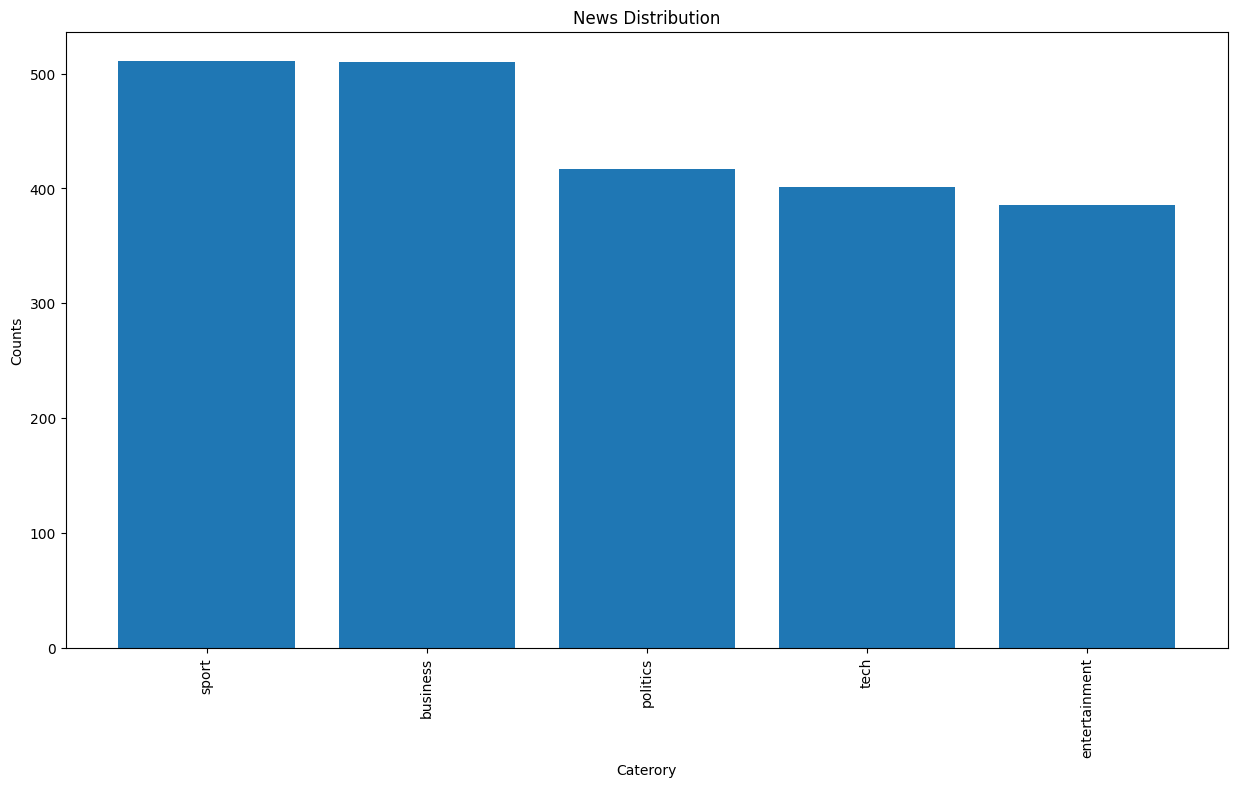

In [12]:
category = bbc_news['category'].value_counts()
category_name = category.index.to_list()
category_counts = category.values.tolist()
plt.figure(figsize=(15,8))
plt.bar(category_name,category_counts)
plt.xlabel('Caterory')
plt.xticks(rotation=90)
plt.ylabel('Counts')
plt.title("News Distribution")
plt.show()

## Text Cleaning
In this step we will convert text to lowercase and removing punctuations,numbers and stopwords.
Since we are performing text classification, removing stopwords help us focus on relevant words which provide semantic value to text analysis.

In [13]:
# def remove_punctuation_numbers(text):
#     tokens = word_tokenize(text)
#     clean_text = ' '.join([word for word in tokens if word.isalpha()])
#     return clean_text
#     #return text.translate(str.maketrans('', '', string.punctuation))

# bbc_news['text_without_punctuations']=bbc_news['text'].apply(remove_punctuation_numbers)

# len(bbc_news['text_without_punctuations'][0].split(' '))

# stop_words = set(stopwords.words('english'))
# def remove_stopwords(text):
#     tokens = word_tokenize(text)
#     clean_text = ' '.join([word for word in tokens if word not in stop_words])
#     return clean_text

# bbc_news['text_without_stopwords']=bbc_news['text_without_punctuations'].apply(remove_stopwords)

# len(bbc_news['text_without_stopwords'][0].split(' '))

In [14]:
# Removing punctuations,numbers and stopwords 
bbc_news['text']=bbc_news['text'].str.lower()
stop_words = set(stopwords.words('english'))
def clean_text(text):
    tokens = word_tokenize(text)
    clean_text = ' '.join([word for word in tokens if word.isalpha() and word not in stop_words])
    return clean_text

In [15]:
bbc_news['processed_text']=bbc_news['text'].apply(clean_text)
bbc_news = bbc_news.drop('text',axis=1)

## Label Encoding
Converting news categories into numerical labels.
Categories are mapped as following:

* 'business': 0,
* 'entertainment': 1,
* 'politics': 2,
* 'sport': 3,
* 'tech': 4


In [16]:
le = LabelEncoder()
bbc_news['encoded_category'] = le.fit_transform(bbc_news['category'])

bbc_news = bbc_news.drop('category',axis=1)

In [17]:
# le_name_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
# print(le_name_mapping)

# Applying Machine Learning 

In [18]:
#Splitting dataset into training(90%) and testing(10%)
X_train,X_test,y_train,y_test = train_test_split(bbc_news['processed_text'],bbc_news['encoded_category'],random_state=42,test_size=0.1)

## TF-IDF Vectorization
Converting our raw text data to numerical vectors.


* fit_transform() on X_train: Learns the vocabulary and calculates IDF (Inverse Document Frequency) scores exclusively from the training set.
* transform() on X_test: Converts test data into vectors based only on the training vocabulary. If you fit the vectorizer on the test set, your model gets indirect clues about test data, resulting in artificially high accuracy metrics that will fail in the real world.


In [19]:
tf_idf_vec = TfidfVectorizer()

X_train_tfidf = tf_idf_vec.fit_transform(X_train)
X_test_tfidf = tf_idf_vec.transform(X_test)

## Training ML model - Logistic Regression

In [20]:
logistic_reg = LogisticRegression()

In [21]:
logistic_reg.fit(X_train_tfidf,y_train)

LogisticRegression()

In [22]:
y_pred = logistic_reg.predict(X_test_tfidf)

## Model Evaluation
Evaluating accuracy score, confusion matrix,classification report

In [23]:
print("Accuracy_score" ,accuracy_score(y_test, y_pred))

Accuracy_score 0.9596412556053812


In [24]:
print("Classification Report \n",classification_report(y_test,y_pred))

Classification Report 
               precision    recall  f1-score   support

           0       0.93      0.91      0.92        46
           1       1.00      0.98      0.99        44
           2       0.94      0.96      0.95        47
           3       0.96      1.00      0.98        48
           4       0.97      0.95      0.96        38

    accuracy                           0.96       223
   macro avg       0.96      0.96      0.96       223
weighted avg       0.96      0.96      0.96       223



In [25]:
cm = confusion_matrix(y_test,y_pred)
print("Confusion Matrix \n",cm)

Confusion Matrix 
 [[42  0  3  1  0]
 [ 0 43  0  0  1]
 [ 2  0 45  0  0]
 [ 0  0  0 48  0]
 [ 1  0  0  1 36]]


In [26]:
logistic_reg.classes_

array([0, 1, 2, 3, 4])

<Figure size 800x800 with 0 Axes>

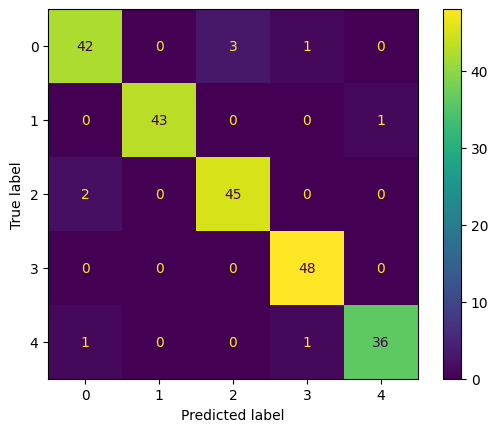

In [27]:
# Creating a visually appealing confusion matrix
#Category mappings ==> 'business': 0,'entertainment': 1,'politics': 2,'sport': 3,'tech': 4
plt.figure(figsize=(8, 8))
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=logistic_reg.classes_)
cm_display.plot()
plt.show()

# Deep Learning – Transformer Model

In [28]:
#Creating a copy of pre-processed dataset and renaming columns as transformers must required ‘label’ as a target column name.
bbc_news_trans_cp = bbc_news.copy()
bbc_news_trans_cp.columns = ['text','label']

#Converting the dataframe to HuggingFace Dataset
bbc_news_trans_ds = Dataset.from_pandas(bbc_news_trans_cp)

#Splitting dataset into training and testing
bbc_news_trans_ds_split = bbc_news_trans_ds.train_test_split(test_size=0.1,seed=42)

bbc_news_trans_ds_split

## Loading a pre-trained Transformer model

pre_trained_model = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(pre_trained_model)
model = AutoModelForSequenceClassification.from_pretrained(
    pre_trained_model,
    num_labels=5
)




config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## Tokenizing data

In [29]:
def tokenize_data(sample_data):
    return tokenizer(sample_data["text"], padding=True, truncation=True , max_length=256)

tokenized_train_dataset = bbc_news_trans_ds_split['train'].map(tokenize_data, batched=True)
tokenized_test_dataset = bbc_news_trans_ds_split['test'].map(tokenize_data, batched=True)

tokenized_train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
tokenized_test_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

Map:   0%|          | 0/2002 [00:00<?, ? examples/s]

Map:   0%|          | 0/223 [00:00<?, ? examples/s]

In [30]:
#len(tokenized_train_dataset)

## Training model

In [31]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {"accuracy": accuracy_score(labels, preds)}

In [32]:
training_args = TrainingArguments(
    output_dir="./news_distilbert_classification_model",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    logging_steps=20
)

In [33]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_test_dataset,#using test dataset as evaluation dataset
    processing_class=tokenizer,
    compute_metrics=compute_metrics
)

In [34]:
print("\nTraining Model …")
trainer.train()


Training Model …


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy
1,0.360336,0.282870,0.964126
2,0.053879,0.318261,0.959641
3,0.031305,0.261218,0.977578


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=189, training_loss=0.4253638091068419, metrics={'train_runtime': 81.0201, 'train_samples_per_second': 74.13, 'train_steps_per_second': 2.333, 'total_flos': 397820880737280.0, 'train_loss': 0.4253638091068419, 'epoch': 3.0})

In [35]:
trainer.state.best_model_checkpoint

'./news_distilbert_classification_model/checkpoint-189'

In [36]:
# Save final model + tokenizer
trainer.save_model("./news_distilbert_classification_model")
tokenizer.save_pretrained("./news_distilbert_classification_model")
print(f"\n  Model saved to → {"./news_distilbert_classification_model"}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


  Model saved to → ./news_distilbert_classification_model


## Transformer Predictions - Building inference pipeline

In [37]:
#Creating a pipeline for inferencing with our best_model_checkpoint, in this case checkpoint-189.
inference_pipeline = pipeline(task="text-classification",model = './news_distilbert_classification_model/checkpoint-189',batch_size=16,truncation=True)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [38]:
#Calling the pipeline to perform inferencing on our test dataset.
list_ds = list(bbc_news_trans_ds_split['test']['text']) #Converting it to list as input is expected in format of list['str']
predictions_on_test_ds = inference_pipeline(list_ds)

In [39]:
predictions_on_test_ds[0:5] # We are getting a dictionary of keys 'label' and 'score'.

[{'label': 'LABEL_1', 'score': 0.9931897521018982},
 {'label': 'LABEL_2', 'score': 0.9925099611282349},
 {'label': 'LABEL_4', 'score': 0.9929726123809814},
 {'label': 'LABEL_1', 'score': 0.9948458671569824},
 {'label': 'LABEL_1', 'score': 0.9946179986000061}]

In [40]:
#predictions_on_test_ds[0]['label'].split('_')[1]

In [41]:
#Function to get only the label number e.g LABEL_1 => 1, LABEL_2 => 2 ; as we are expecting only a list of integers for different categories
y_pred = []
def get_label(predictions_on_test_ds):
    for prediction in predictions_on_test_ds:
        label = prediction['label'].split("_")[1]
        y_pred.append(int(label))
    return y_pred
        
y_pred = get_label(predictions_on_test_ds)

In [42]:
#y_pred[0:10] 

## Model Evaluation

In [43]:
# We need the actual labels of test dataset so that we can calculate metrics such as accuracy score, confusion matrix 
y_true = list(bbc_news_trans_ds_split['test']['label'])

In [44]:
print("Accuracy_score using transformer :" ,accuracy_score(y_true, y_pred))

Accuracy_score using transformer : 0.9775784753363229


In [45]:
cm_transformer = confusion_matrix(y_true,y_pred)
print("Confusion Matrix \n",cm_transformer)

Confusion Matrix 
 [[45  1  1  0  1]
 [ 0 44  1  0  0]
 [ 0  0 38  0  1]
 [ 0  0  0 56  0]
 [ 0  0  0  0 35]]


<Figure size 800x800 with 0 Axes>

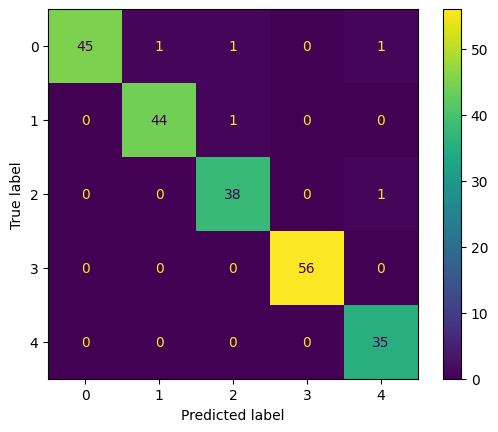

In [46]:
# Creating a visually appealing confusion matrix
#Category mappings ==> 'business': 0,'entertainment': 1,'politics': 2,'sport': 3,'tech': 4
plt.figure(figsize=(8, 8))
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm_transformer,
                              display_labels=logistic_reg.classes_)
cm_display.plot()
plt.show()

# Performance Comparison

## Comparing ML vs Transformer predictions

Let's take a look at **accuracy score**: <br>
Using Logistic regression model : **approx. 96%** <br>
Using distilbert-base-uncased transformer model : **approx. 98%**

Although in our case the difference might not seem that vast, but the transformer model works on understanding the context of text rather than just the keywords.<br>
Therefore is it able to establish relation between words and predict the labels more accurately.

# Generative AI – RAG (Retrieval-Augmented Generation)

## Document Creation
Convert cleaned news articles into document format where each article acts as a knowledge source.

In [47]:
''' The bbc_news dataframe has two columns 'processed_text' and 'encoded_category'. We are going to load the text data from
processed_text column to a news_articles.txt document which will act as our knowledge base''' 

#bbc_news['processed_text'].to_csv('news_articles.txt', index=False, header=False)
#bbc_news_og_ds.columns
bbc_news_og_ds['text'].to_csv('news_articles.txt', index=False, header=False)

In [48]:
# Loading the news_articles.txt as document
loader = TextLoader("news_articles.txt")
documents = loader.load()

In [66]:
# Chunking: Split text into manageable pieces
text_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
chunks = text_splitter.split_documents(documents)

## Embedding Generation and Vector Database

In [67]:
# Embedding & Vector Store: Convert text to vectors and store them
embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
vectorstore = FAISS.from_documents(chunks, embeddings)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [68]:
# Generation: Use an LLM to answer using the retrieved context
# We use Qwen3 model with 0.6 billion parameters
qa_pipeline = pipeline("text-generation",
                       model="Qwen/Qwen3-0.6B",
                      device=0 if torch.cuda.is_available() else -1)

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


In [74]:
#Setting seed for response reproducibility
transformers.set_seed(42) 

## RAG-Based Question Answering

In [71]:
query_list = ['Summarize sports news article','What are the key points in this document?','Find top 3 news related to technology']
LLM_response = []
for query in query_list:
    docs = vectorstore.similarity_search(query,k=2) #Getting 2 relevant chunks for the query
    context =" ".join([document.page_content for document in docs]) #Combining the chunks to form context for the LLM
    prompt = f"Context: {context}\n\nQuestion: {query}\n\nAnswer:"
    result = qa_pipeline(prompt, max_new_tokens=100,do_sample=False)
    print(f"LLM Response: {result[0]['generated_text']}")
    print("---------------------------------------------------------------")
    #LLM_response.append(result[0]['generated_text'])

Both `max_new_tokens` (=100) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=100) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


LLM Response: Context: giving a greater depth to the growing wealth of analysis available during sports broadcasts. the technology has been created by bbc research and development for bbc broadcast and bbc outside broadcasts. bbc sport is the first client to start using the system.  in order to keep audiences growing and growing... we need to work closely with people who create technology and innovation to bring sport to life   said andrew thompson  the bbc s head of development  new media and sports news.  we want sporting rivals go to extra time the current slew of sports games offers unparalleled opportunities for fans who like to emulate on-field action without ever moving from the couch.  the two giants in the field - espn and ea sports - have been locked in a heavyweight battle for years. the latter is the world s largest games manufacturer. years of experience mean that the titles in their steady flow of sport sims are finely honed  massively entertaining and ooze flair. sports 

Both `max_new_tokens` (=100) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


LLM Response: Context: to transfer technology  training capability and content from projects with foreign partners.  we are defending our national sovereignty over the use of our national resources which must serve the endogenous development of the nation   mr alvarez said.  for this reason we are reviewing all memorandums of understanding  all letters of intent  all agreements that have been signed  all contracts  to check which of these comply with these directives.  everything  absolutely everything  has to be propaganda exercise to try to sell the new eu to the country in advance of the forthcoming referendum and general election    he asked. the tory spokesman also criticised the government for claiming the eu constitution would make europe easier to understand.  the government  last week  had to publish a commentary of 500 pages to try and explain this  easy and simple  constitution to the british people   he said.  who are they trying to kid   the proposed question for the const